# Affine rectification

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/magrilu/cv-dojo/blob/main/notebooks/04-rectification/affine.ipynb)

*Companion to Algorithm 1, Section 1.3.*

Perspective destroys parallelism: two rails that never meet in the world do meet
on the page. **Affine rectification** puts it back. It does not recover angles or
length ratios — that comes later, in the metric step — but it does recover
everything affine: parallelism, midpoints, ratios of lengths along a line.

The whole method rests on one observation. Under perspective the line at infinity
$\ell_\infty$ no longer sits at $(0:0:1)$; it lands somewhere in the image as
$\ell'_\infty$, the **vanishing line**. Send it back where it belongs and the
affine structure returns with it.

Two pairs of parallel lines are enough:

| | |
|---|---|
| 1 | Intersect each pair to get the vanishing points $\mathbf{U}' = \mathbf{a}' \times \mathbf{c}'$, $\mathbf{V}' = \mathbf{b}' \times \mathbf{d}'$ |
| 2 | Join them: $\ell'_\infty = \mathbf{U}' \times \mathbf{V}'$ |
| 3 | Normalise $\ell'_\infty$ |
| 4 | Build $H_P$ so that $H_P^{-\top}\,\ell'_\infty = (0:0:1)^\top$ |

In [1]:
# On Colab, fetch the repository. Locally this is a no-op.
import os, sys, subprocess
if "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ:
    if not os.path.isdir("cv-dojo"):
        subprocess.run(["git", "clone", "-q",
                        "https://github.com/magrilu/cv-dojo.git"], check=True)
    os.chdir("cv-dojo")

sys.path.insert(0, os.path.abspath("../../src"))   # local run, from notebooks/04-rectification
sys.path.insert(0, os.path.abspath("src"))        # Colab run, from the repo root

import numpy as np
import matplotlib.pyplot as plt
import cvdojo as cv

plt.rcParams["figure.figsize"] = (7, 5)

## The image

`load_facade` picks up `data/facade.jpg` if you have put one there, and otherwise
synthesises a facade under a known homography. Start with the synthetic one: the
ground truth is available, so you can check the answer rather than eyeball it.

synthetic - (520, 700, 3)


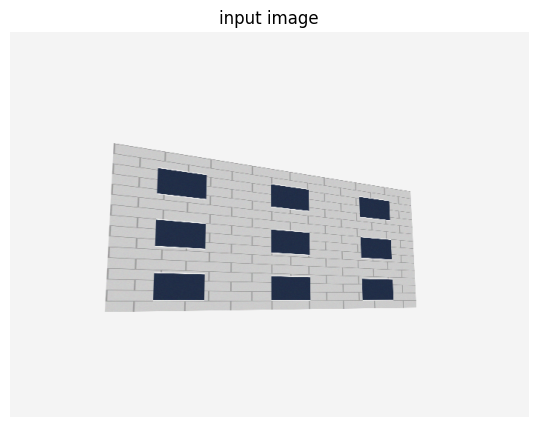

In [2]:
img, H_gt = cv.load_facade()
cv.show(img, title="input image")
print("synthetic" if H_gt is not None else "photograph", "-", img.shape)

## The four segments

Here is the design decision worth flagging. The notebook ships with **precomputed
endpoints**, so it runs top to bottom on any machine, including Colab, with nothing
to click. The interactive selection lives in the next cell and is optional — that is
the one to use in the lecture room.

The naming follows the book: $\{\mathbf{a}', \mathbf{c}'\}$ are the images of one
family of parallel world lines, $\{\mathbf{b}', \mathbf{d}'\}$ of a second family.

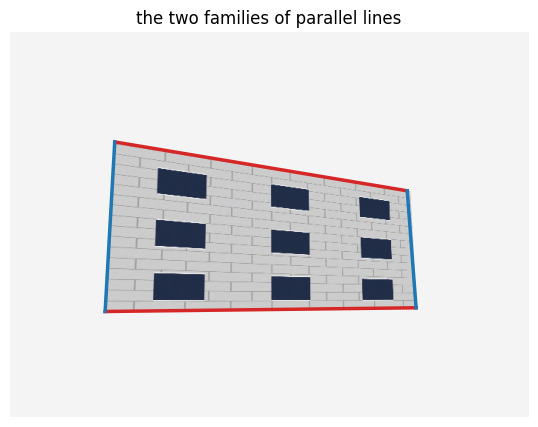

In [3]:
seg = dict(cv.DEFAULT_SEGMENTS)   # keys: 'a', 'c' (first family), 'b', 'd' (second)

ax = cv.show(img, title="the two families of parallel lines")
for k, col in [("a", "tab:red"), ("c", "tab:red"),
               ("b", "tab:blue"), ("d", "tab:blue")]:
    cv.draw_segment(ax, seg[k], color=col)

### Optional: pick them yourself

Uncomment and run to click the eight endpoints (`a` then `c` in red, `b` then `d`
in blue). Needs `%matplotlib widget` and `ipympl`, which works locally but not on
Colab — there, edit the numbers in `seg` by hand instead.

In [4]:
# %matplotlib widget
# ax = cv.show(img, title="click 8 points: a1 a2 c1 c2 b1 b2 d1 d2")
# pts = plt.ginput(8, timeout=0)
# seg = {k: [pts[2*i], pts[2*i+1]] for i, k in enumerate(["a", "c", "b", "d"])}
# print(seg)

## Steps 1-3: the vanishing line

Each segment gives a line through its endpoints, $\ell = \mathbf{x}_1 \times \mathbf{x}_2$.
Intersecting lines within a family gives a vanishing point; joining the two
vanishing points gives $\ell'_\infty$.

The normalisation on line 3 of the algorithm is not cosmetic. Vanishing points
often land thousands of pixels outside the frame, so $\ell'_\infty$ comes out with
a third coordinate several orders of magnitude larger than the first two. Left
alone, that imbalance propagates straight into the bottom row of $H_P$.

In [5]:
a, c = cv.seg_to_line(seg["a"]), cv.seg_to_line(seg["c"])
b, d = cv.seg_to_line(seg["b"]), cv.seg_to_line(seg["d"])

U = cv.meet(a, c)          # first vanishing point
V = cv.meet(b, d)          # second vanishing point
l_inf = cv.normalize_line(cv.join(U, V))

print("U' =", cv.cartesian(U).ravel())
print("V' =", cv.cartesian(V).ravel())
print("l'_inf =", l_inf)

U' = [1419.51237582  361.62485267]
V' = [  307.81257809 -2790.46772178]
l'_inf = [ 9.43065754e-01 -3.32606350e-01 -1.21841479e+03]


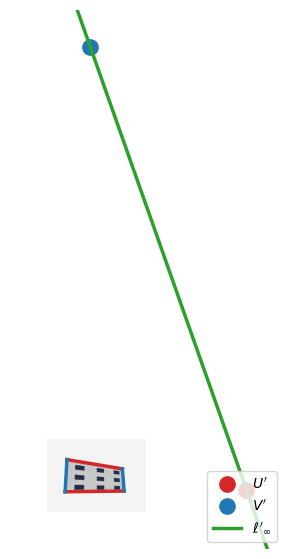

In [6]:
# Both vanishing points usually fall well outside the image: widen the axes.
u, v = cv.cartesian(U).ravel(), cv.cartesian(V).ravel()
xs = [0, img.shape[1], u[0], v[0]]
ys = [0, img.shape[0], u[1], v[1]]
pad = 0.08 * max(max(xs) - min(xs), max(ys) - min(ys))

fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(np.clip(img, 0, 1))
for k, col in [("a", "tab:red"), ("c", "tab:red"),
               ("b", "tab:blue"), ("d", "tab:blue")]:
    cv.draw_segment(ax, seg[k], color=col)
ax.plot(*u, "o", color="tab:red", ms=11, label="$U'$")
ax.plot(*v, "o", color="tab:blue", ms=11, label="$V'$")
ax.set_xlim(min(xs) - pad, max(xs) + pad)
ax.set_ylim(max(ys) + pad, min(ys) - pad)
cv.draw_line(ax, l_inf, xlim=ax.get_xlim(), color="tab:green", lw=2.5,
             label=r"$\ell'_\infty$")
ax.legend(loc="lower right")
ax.set_axis_off()

## Step 4: the rectifying homography

$$
H_P = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ \ell_1 & \ell_2 & \ell_3 \end{bmatrix}
$$

The top two rows are a free choice — any affinity there would do, since the result
is only defined up to one. All the work is in the bottom row.

Lines transform by the inverse transpose, so the check is
$H_P^{-\top} \ell'_\infty = (0:0:1)^\top$.

In [7]:
H_P = cv.H_from_vanishing_line(l_inf)
print(H_P, "\n")

check = np.linalg.inv(H_P).T @ l_inf
print("H_P^-T l'_inf =", np.round(check / check[2], 12))

[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [ 9.43065754e-01 -3.32606350e-01 -1.21841479e+03]] 

H_P^-T l'_inf = [-0. -0.  1.]


## Warping

One practical note that costs an afternoon if you meet it cold: `skimage.transform.warp`
pulls each output pixel from the input, so it wants the **inverse** map, and it keeps
the original canvas — unlike MATLAB's `imwarp`, which sizes the output for you.
`cv.warp_image` handles both, and fits the canvas to the region of interest rather
than to the image corners, which after rectification are usually far away.

<Axes: title={'center': 'affine rectified'}>

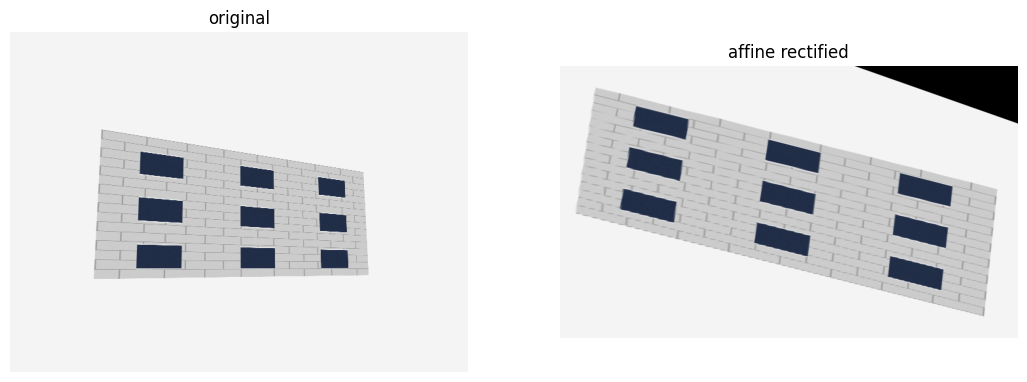

In [8]:
roi = np.vstack([seg[k] for k in ("a", "c", "b", "d")])
rect = cv.warp_image(img, H_P, roi=roi, max_side=900)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cv.show(img, ax=axes[0], title="original")
cv.show(rect, ax=axes[1], title="affine rectified")

The facade is now a parallelogram. It is still sheared and rotated, and it should
be: affine rectification recovers the plane only up to an affinity. Angles and
length ratios need the metric step.

## Checking it worked

Eyeballing parallel lines is unreliable. Transform the lines themselves and read
off the vanishing points: if the rectification is right, they have moved to
infinity, so their third coordinate should be zero (to numerical precision).

In [9]:
Hinv_T = np.linalg.inv(H_P).T
a_r, c_r = Hinv_T @ a, Hinv_T @ c
b_r, d_r = Hinv_T @ b, Hinv_T @ d

for name, (p, q) in [("a x c", (a_r, c_r)), ("b x d", (b_r, d_r))]:
    w = cv.meet(p, q)
    print(f"{name}: third coordinate = {w[2] / np.linalg.norm(w):+.2e}")

a x c: third coordinate = +0.00e+00
b x d: third coordinate = -4.56e-17


## Where it breaks

Worth running before trusting this on a photograph. Nudge one endpoint by a few
pixels and watch what happens to $\ell'_\infty$: the more nearly parallel the
segments look in the image, the further out the vanishing point goes, and the
worse conditioned everything downstream becomes. This is the failure mode behind
the bitangent construction in Section 1.7.

In [10]:
rng = np.random.default_rng(0)
base = cv.normalize_line(cv.join(cv.meet(a, c), cv.meet(b, d)))

for sigma in (0.0, 0.5, 1.0, 2.0):
    devs = []
    for _ in range(200):
        pert = {k: np.asarray(v, float) + rng.normal(0, sigma, (2, 2))
                for k, v in seg.items()}
        L = {k: cv.seg_to_line(pert[k]) for k in pert}
        l = cv.normalize_line(cv.join(cv.meet(L["a"], L["c"]),
                                      cv.meet(L["b"], L["d"])))
        devs.append(np.linalg.norm(l - base) / max(np.linalg.norm(base), 1e-12))
    print(f"endpoint noise {sigma:.1f} px  ->  relative error on l'_inf "
          f"{np.mean(devs):.4f}")

endpoint noise 0.0 px  ->  relative error on l'_inf 0.0000
endpoint noise 0.5 px  ->  relative error on l'_inf 0.0099
endpoint noise 1.0 px  ->  relative error on l'_inf 0.0193
endpoint noise 2.0 px  ->  relative error on l'_inf 0.0383


## Exercises

1. Replace the synthetic facade with a photograph of your own: drop it in
   `data/facade.jpg` and pick the segments interactively.
2. With the synthetic image you have `H_gt`. The composition $H_P \, H_{gt}$
   should be an affinity — check that its bottom row is $(0, 0, \star)$, and
   quantify how far off it is.
3. Recover the vanishing line from *three* equally spaced coplanar lines instead
   of two pairs of parallel ones (cross-ratio construction).
4. Continue to the metric step: five pairs of orthogonal lines give
   $\hat{C}^*_\infty$, and from it $H_A$. See Algorithm 2, Section 1.5.